In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("cars_versions_specs.csv")

In [3]:
df.head()

,brand,model,version,price,caractéristiques_disponibilité,caractéristiques_carrosserie,caractéristiques_garantie,caractéristiques_nombre_de_places,caractéristiques_nombre_de_portes,motorisation_nombre_de_cylindres,...,audio_et_communication_ecran_central,equipements_intérieurs_sellerie,equipements_intérieurs_volant,equipements_intérieurs_toit,equipements_fonctionnels_frein_de_stationnement,equipements_fonctionnels_modes_de_conduite,performances_autonomie_électrique_(wltp),consommation_consommation_électrique_(wltp),consommation_temps_de_recharge_normale_(ac),consommation_temps_de_recharge_rapide_(dc)
0,Alfa-Romeo,Alfa Romeo Giulia,Alfa Romeo Giulia,198000,Indisponible,Berline,3 ans,5,4,4.0,...,7 pouces,Cuir,Cuir | Multi-fonctions | Avec palettes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alfa-Romeo,Alfa Romeo Stelvio,Alfa Romeo Stelvio,265000,Indisponible,SUV,3 ans,5,5,4.0,...,Tactile | 6.5 pouces,Cuir,Cuir | Chauffant | Multi-fonctions | Avec pale...,Ouvrant | Panoramique | + 7000 DT,NaN,NaN,NaN,NaN,NaN,NaN
2,Audi,Audi A3 Sportback,35 TFSI Iconic Line,139990,Disponible,Compacte,3 ans,5,5,4.0,...,Tactile | 10.1 pouces,Tissu,Cuir | 3 branches | Multi-fonctions | Avec pal...,NaN,Éléctrique,NaN,NaN,NaN,NaN,NaN
3,Audi,Audi A3 Sportback,35 TFSI Tech Line,154000,Disponible,Compacte,3 ans,5,5,4.0,...,Tactile | 10.1 pouces,Tissu,Cuir | 3 branches | Multi-fonctions | Avec pal...,Panoramique | En verre,Éléctrique,NaN,NaN,NaN,NaN,NaN
4,Audi,Audi A3 Sportback,35 TFSI S-Line,179990,Disponible,Compacte,3 ans,5,5,4.0,...,Tactile | 10.1 pouces,Similicuir/Tissu,Cuir | 3 branches | Multi-fonctions | Sport | ...,Panoramique | En verre,Éléctrique,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isnull().sum()

brand                                                0
model                                                0
version                                              0
price                                                0
caractéristiques_disponibilité                       0
caractéristiques_carrosserie                         0
caractéristiques_garantie                            0
caractéristiques_nombre_de_places                    0
caractéristiques_nombre_de_portes                    0
motorisation_nombre_de_cylindres                    94
motorisation_energie                                 0
motorisation_puissance_fiscale                       0
motorisation_puissance_(ch.din)                      0
transmission_boîte                                   0
transmission_nombre_de_rapports                    114
transmission_transmission                            0
consommation_consommation_mixte                     94
aides_à_la_conduite_aide_au_stationnement           54
equipement

In [5]:
df1=df.drop(['consommation_temps_de_recharge_rapide_(dc)','consommation_temps_de_recharge_normale_(ac)','consommation_consommation_électrique_(wltp)','performances_autonomie_électrique_(wltp)', 'equipements_extérieurs_jantes'], axis=1)

In [6]:
df1.columns

Index(['brand', 'model', 'version', 'price', 'caractéristiques_disponibilité',
       'caractéristiques_carrosserie', 'caractéristiques_garantie',
       'caractéristiques_nombre_de_places',
       'caractéristiques_nombre_de_portes', 'motorisation_nombre_de_cylindres',
       'motorisation_energie', 'motorisation_puissance_fiscale',
       'motorisation_puissance_(ch.din)', 'transmission_boîte',
       'transmission_nombre_de_rapports', 'transmission_transmission',
       'consommation_consommation_mixte',
       'aides_à_la_conduite_aide_au_stationnement',
       'audio_et_communication_ecran_central',
       'equipements_intérieurs_sellerie', 'equipements_intérieurs_volant',
       'equipements_intérieurs_toit',
       'equipements_fonctionnels_frein_de_stationnement',
       'equipements_fonctionnels_modes_de_conduite'],
      dtype='object')

In [8]:
df1.head()

,brand,model,version,price,caractéristiques_disponibilité,caractéristiques_carrosserie,caractéristiques_garantie,caractéristiques_nombre_de_places,caractéristiques_nombre_de_portes,motorisation_nombre_de_cylindres,...,transmission_nombre_de_rapports,transmission_transmission,consommation_consommation_mixte,aides_à_la_conduite_aide_au_stationnement,audio_et_communication_ecran_central,equipements_intérieurs_sellerie,equipements_intérieurs_volant,equipements_intérieurs_toit,equipements_fonctionnels_frein_de_stationnement,equipements_fonctionnels_modes_de_conduite
0,Alfa-Romeo,Alfa Romeo Giulia,Alfa Romeo Giulia,198000,Indisponible,Berline,3 ans,5,4,4.0,...,8.0,Propulsion,5.9 L/100 km,Radar de recul | Radar avant,7 pouces,Cuir,Cuir | Multi-fonctions | Avec palettes,NaN,NaN,NaN
1,Alfa-Romeo,Alfa Romeo Stelvio,Alfa Romeo Stelvio,265000,Indisponible,SUV,3 ans,5,5,4.0,...,8.0,Intégrale,7 L/100 km,Radar de recul | Radar avant | Caméra de recul,Tactile | 6.5 pouces,Cuir,Cuir | Chauffant | Multi-fonctions | Avec pale...,Ouvrant | Panoramique | + 7000 DT,NaN,NaN
2,Audi,Audi A3 Sportback,35 TFSI Iconic Line,139990,Disponible,Compacte,3 ans,5,5,4.0,...,8.0,Traction,5.4 L/100 km,Radar de recul | Radar avant | Caméra de recul...,Tactile | 10.1 pouces,Tissu,Cuir | 3 branches | Multi-fonctions | Avec pal...,NaN,Éléctrique,NaN
3,Audi,Audi A3 Sportback,35 TFSI Tech Line,154000,Disponible,Compacte,3 ans,5,5,4.0,...,8.0,Traction,5.4 L/100 km,Radar de recul | Radar avant | Caméra de recul...,Tactile | 10.1 pouces,Tissu,Cuir | 3 branches | Multi-fonctions | Avec pal...,Panoramique | En verre,Éléctrique,NaN
4,Audi,Audi A3 Sportback,35 TFSI S-Line,179990,Disponible,Compacte,3 ans,5,5,4.0,...,8.0,Traction,5.4 L/100 km,Radar de recul | Radar avant | Caméra de recul...,Tactile | 10.1 pouces,Similicuir/Tissu,Cuir | 3 branches | Multi-fonctions | Sport | ...,Panoramique | En verre,Éléctrique,NaN


In [9]:
df1.isnull().sum()

brand                                                0
model                                                0
version                                              0
price                                                0
caractéristiques_disponibilité                       0
caractéristiques_carrosserie                         0
caractéristiques_garantie                            0
caractéristiques_nombre_de_places                    0
caractéristiques_nombre_de_portes                    0
motorisation_nombre_de_cylindres                    94
motorisation_energie                                 0
motorisation_puissance_fiscale                       0
motorisation_puissance_(ch.din)                      0
transmission_boîte                                   0
transmission_nombre_de_rapports                    114
transmission_transmission                            0
consommation_consommation_mixte                     94
aides_à_la_conduite_aide_au_stationnement           54
audio_et_c

In [10]:
numerical_features = [
    'price',
    'caractéristiques_nombre_de_places',
    'motorisation_nombre_de_cylindres',
    'motorisation_puissance_(ch.din)',
    'transmission_nombre_de_rapports'
]
categorical_features = [
    'brand',
    'model',
    'version',
    'caractéristiques_nombre_de_portes',
    'caractéristiques_disponibilité',
    'caractéristiques_carrosserie',
    'caractéristiques_garantie',
    'motorisation_energie',
    'transmission_boîte',
    'transmission_transmission',
    'equipements_intérieurs_sellerie',
    'equipements_intérieurs_volant',
    'equipements_intérieurs_toit',
    'equipements_fonctionnels_frein_de_stationnement',
    'equipements_fonctionnels_modes_de_conduite',
    'consommation_consommation_mixte',
    'motorisation_puissance_fiscale'
]

In [11]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [12]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [13]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [18]:
X = preprocessor.fit_transform(df1)

In [19]:
print(X.shape)

(549, 1332)


In [28]:
import mlflow
import mlflow.sklearn

from sklearn.cluster import KMeans
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import silhouette_score

In [29]:
k = 4
model = KMeans(n_clusters=k, random_state=42)
clusters = model.fit_predict(X)


In [30]:
score = silhouette_score(X, clusters)


In [31]:
mlflow.log_param("n_clusters", k)
mlflow.log_param("algorithm", "KMeans")

'KMeans'

In [ ]:
mlflow.log_metric("silhouette_score", score)
mlflow.log_metric("inertia", model.inertia_)

In [33]:
mlflow.sklearn.log_model(model, "kmeans_model")


2026/02/17 10:44:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/17 10:44:15 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\rania\AppData\Local\Temp\tmpg5km38pg\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.0.2', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 
2026/02/17 10:44:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [34]:
mlflow.sklearn.log_model(scaler, "scaler")

2026/02/17 10:44:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/17 10:44:35 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/02/17 10:44:41 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\rania\AppData\Local\Temp\tmp1z7adcnm\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.0.2', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 
2026/02/17 10:44:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


ValueError: 'c' argument has 549 elements, which is inconsistent with 'x' and 'y' with size 1.

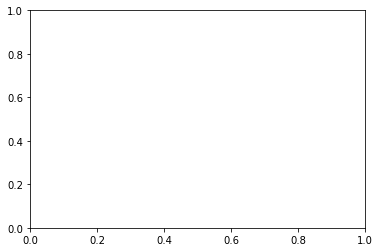

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1], c=clusters)
plt.title("Clusters")
plt.savefig("clusters.png")
mlflow.log_artifact("clusters.png")

SyntaxError: invalid syntax (3574192917.py, line 1)